In [23]:
# import necessary libraries:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

In [24]:
# run code from data_input folder:# run code from data_input folder:
os.chdir('C:/Users/ccwis/OneDrive/Documents/1. MEng - Data Science/Project/factor_timing/data_input')

In [25]:
data = pd.read_csv("factor_returns.csv", parse_dates=['Date'])
data = data.set_index('Date')

#df_benchmark = pd.read_csv("benchmark_returns.csv", parse_dates=['Date'])
#df_benchmark = df_benchmark.set_index('Date')

#data = pd.concat([df_benchmark,df_factors], axis=1, join='inner')
data = data.dropna()

In [26]:
print(data)

            Momentum     Value   Quality
Date                                    
2007-03-05  0.018613  0.015753 -0.010966
2007-03-12 -0.012887 -0.020257  0.048512
2007-03-19  0.060268  0.052751  0.014917
2007-03-26  0.022670  0.007935  0.007713
2007-04-02  0.010079  0.009888  0.018702
...              ...       ...       ...
2025-03-03  0.049395  0.011621  0.076581
2025-03-10 -0.009996 -0.002634  0.041062
2025-03-17  0.040341  0.006385  0.018397
2025-03-24  0.008068 -0.006651  0.020056
2025-03-31 -0.017642 -0.096445 -0.010625

[944 rows x 3 columns]


In [27]:
# List of factor columns and the benchmark
cols = ['Momentum', 'Value', 'Quality']

# Compute cumulative returns for each column
cum_returns = (1 + data[cols]).cumprod() - 1

# Optional: format as percentages
cum_returns = cum_returns * 100



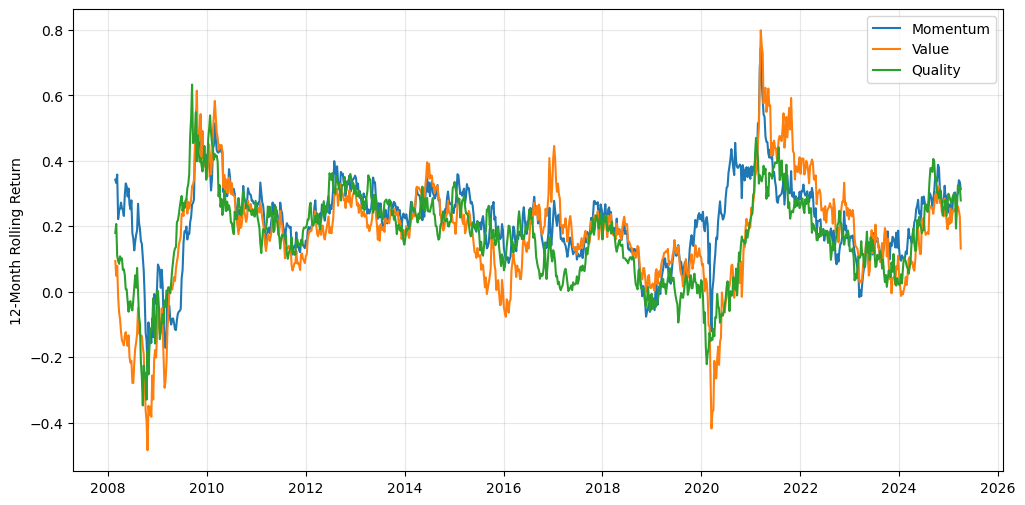

In [28]:
rolling_12m = data[cols].rolling(52).sum()  # 52 weeks

plt.figure(figsize=(12,6))
plt.plot(rolling_12m.index, rolling_12m)
#plt.title("12-Month Rolling Factor Risk Premia")
plt.ylabel("12-Month Rolling Return")
plt.legend(cols)
plt.grid(True, alpha=0.3)
plt.show()


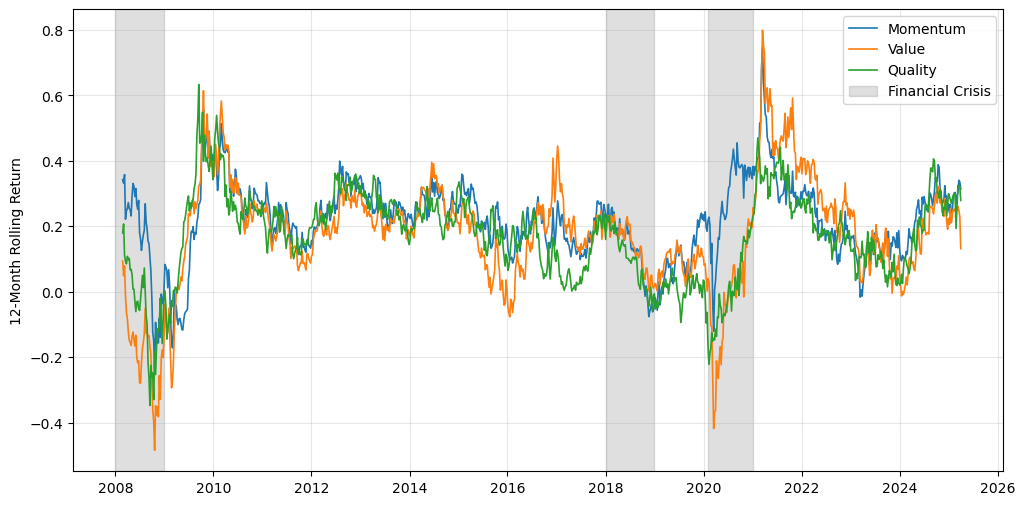

In [29]:
# === 12-month rolling factor premia ===
rolling_12m = data[cols].rolling(52).sum()

# === Crisis windows to shade (tuples of start/end dates) ===
crisis_periods = [
    ("2008-01-01", "2008-12-31"),   # Global Financial Crisis
    ("2018-01-01", "2018-12-31"),   # South African recession
    ("2020-02-01", "2020-12-31"),   # Pandemic period
]

plt.figure(figsize=(12, 6))

# Plot the rolling factor returns (thin lines)
plt.plot(rolling_12m.index, rolling_12m, linewidth=1.2)

# === Shade crisis periods ===
for start, end in crisis_periods:
    plt.axvspan(pd.to_datetime(start),
                pd.to_datetime(end),
                color="grey",
                alpha=0.25,
                label="Crisis period")

#plt.title("12-Month Rolling Factor Risk Premia with Crisis Periods")
plt.ylabel("12-Month Rolling Return")
plt.legend(cols + ["Financial Crisis"])
plt.grid(True, alpha=0.3)
plt.show()


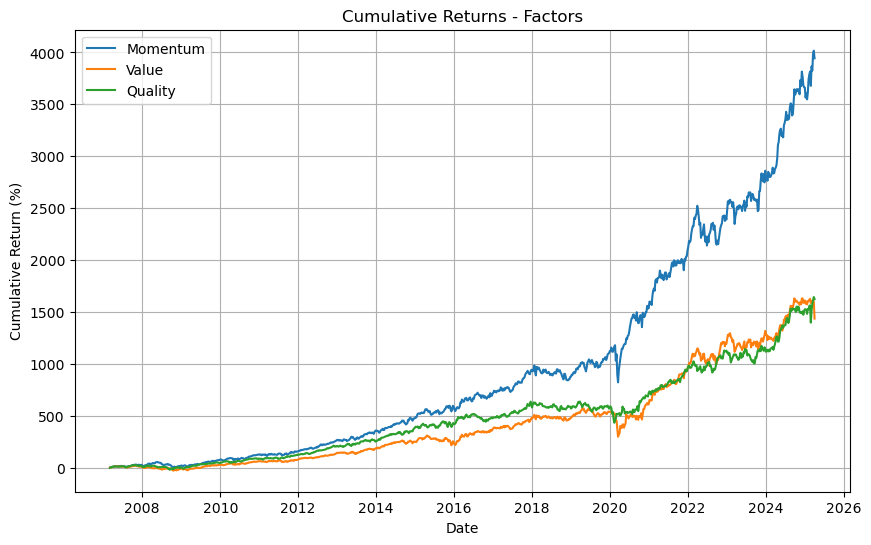

In [30]:
plt.figure(figsize=(10, 6))
for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col)

plt.title("Cumulative Returns - Factors")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Pearson:
corr_matrix = data[['Momentum', 'Value', 'Quality']].corr()

print(corr_matrix)



          Momentum     Value   Quality
Momentum  1.000000  0.798382 -0.042678
Value     0.798382  1.000000 -0.027308
Quality  -0.042678 -0.027308  1.000000


In [32]:
# Spearman
spearman_corr = data[['Momentum', 'Value', 'Quality']].corr(method='spearman')

print(spearman_corr)


          Momentum     Value   Quality
Momentum  1.000000  0.804940 -0.038816
Value     0.804940  1.000000 -0.043401
Quality  -0.038816 -0.043401  1.000000


In [34]:
# Kendall
kendall_corr = data[['Momentum', 'Value', 'Quality']].corr(method='kendall')

print(kendall_corr)


          Momentum     Value   Quality
Momentum  1.000000  0.636785 -0.026830
Value     0.636785  1.000000 -0.030101
Quality  -0.026830 -0.030101  1.000000


In [45]:
rolling_corr = (
    data[['Momentum', 'Value', 'Quality']]
    .rolling(window=52)
    .corr()
)

rolling_mv = data['Momentum'].rolling(52).corr(data['Value'])
rolling_mq = data['Momentum'].rolling(52).corr(data['Quality'])
rolling_vq = data['Value'].rolling(52).corr(data['Quality'])


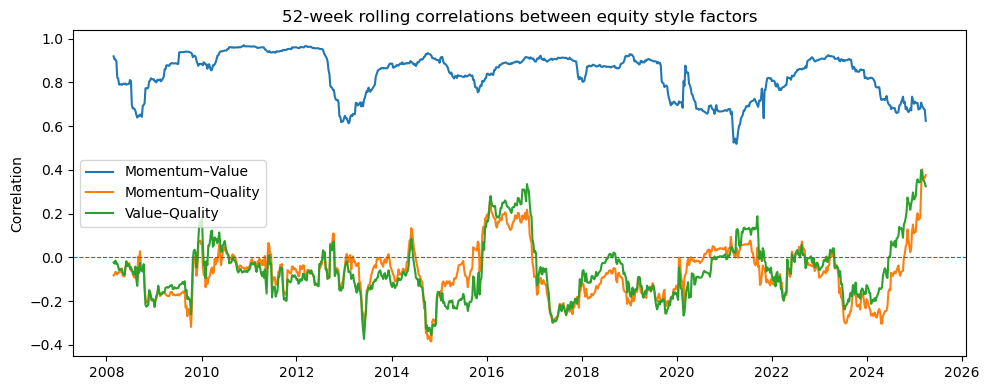

In [46]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(rolling_mv, label='Momentum–Value')
ax.plot(rolling_mq, label='Momentum–Quality')
ax.plot(rolling_vq, label='Value–Quality')

ax.axhline(0, linestyle='--', linewidth=0.8)
ax.set_title('52-week rolling correlations between equity style factors')
ax.set_ylabel('Correlation')
ax.legend()
plt.tight_layout()
plt.show()


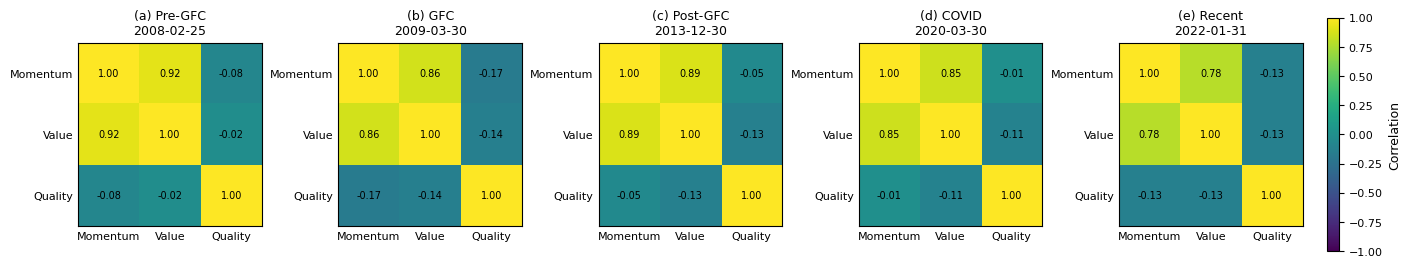

In [47]:
import matplotlib.pyplot as plt
import numpy as np

cols = ['Momentum', 'Value', 'Quality']

# rolling-correlation snapshot dates (already aligned to available dates)
snapshot_dates = nearest_dates  

regime_labels = [
    'Pre-GFC',
    'GFC',
    'Post-GFC',
    'COVID',
    'Recent'
]

fig, axes = plt.subplots(
    1, len(snapshot_dates),
    figsize=(14, 3),
    constrained_layout=True
)

vmin, vmax = -1, 1
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

for ax, d, panel, regime in zip(axes, snapshot_dates, panel_labels, regime_labels):
    corr_mat = roll_corr.loc[d].reindex(index=cols, columns=cols)

    im = ax.imshow(
        corr_mat.values,
        vmin=vmin,
        vmax=vmax,
        aspect='equal'
    )

    # Title with regime label
    ax.set_title(
        f"{panel} {regime}\n{d.strftime('%Y-%m-%d')}",
        fontsize=9
    )

    # Axis formatting
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, fontsize=8)
    ax.set_yticklabels(cols, fontsize=8)
    ax.tick_params(axis='both', which='both', length=0)

    # Value annotations (subtle)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(
                j, i,
                f"{corr_mat.values[i, j]:.2f}",
                ha='center',
                va='center',
                fontsize=7
            )

# Shared colourbar
cbar = fig.colorbar(
    im,
    ax=axes,
    location='right',
    shrink=0.8,
    pad=0.02
)
cbar.set_label('Correlation', fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.show()



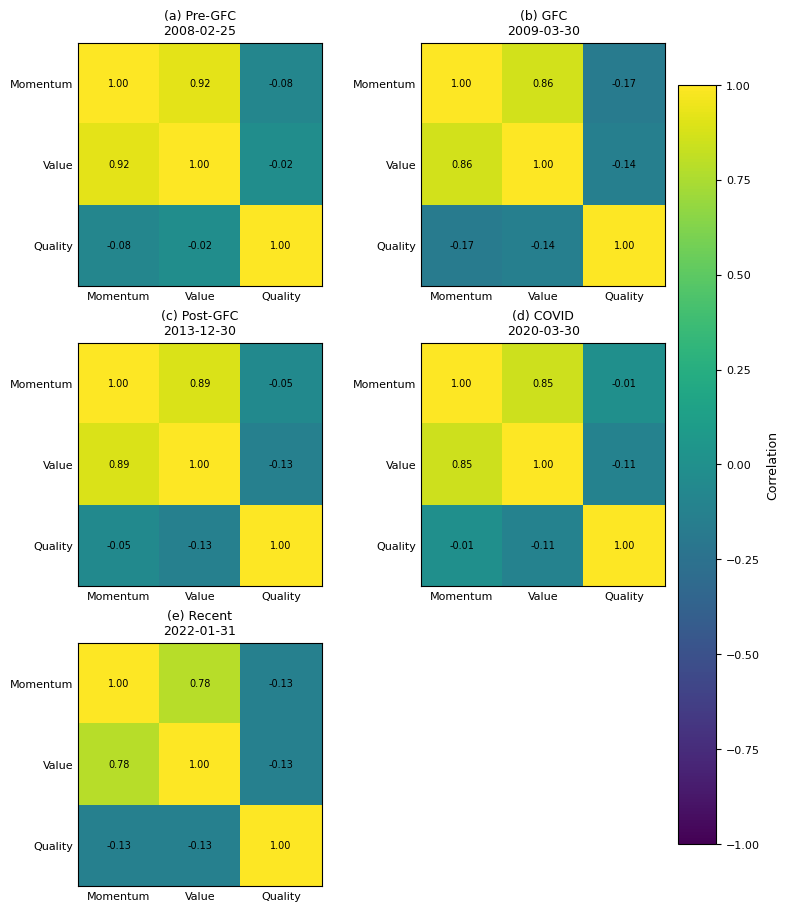

In [48]:
import matplotlib.pyplot as plt
import numpy as np

cols = ['Momentum', 'Value', 'Quality']

snapshot_dates = nearest_dates
regime_labels = ['Pre-GFC', 'GFC', 'Post-GFC', 'COVID', 'Recent']
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

fig, axes = plt.subplots(
    3, 2,
    figsize=(8, 9),   # portrait-friendly
    constrained_layout=True
)

axes = axes.flatten()

vmin, vmax = -1, 1

for ax, d, panel, regime in zip(axes, snapshot_dates, panel_labels, regime_labels):
    corr_mat = roll_corr.loc[d].reindex(index=cols, columns=cols)

    im = ax.imshow(
        corr_mat.values,
        vmin=vmin,
        vmax=vmax,
        aspect='equal'
    )

    ax.set_title(
        f"{panel} {regime}\n{d.strftime('%Y-%m-%d')}",
        fontsize=9
    )

    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, fontsize=8)
    ax.set_yticklabels(cols, fontsize=8)
    ax.tick_params(axis='both', which='both', length=0)

    # annotate values
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(
                j, i,
                f"{corr_mat.values[i, j]:.2f}",
                ha='center',
                va='center',
                fontsize=7
            )

# Turn off the unused sixth subplot
axes[-1].axis('off')

# Shared colourbar
cbar = fig.colorbar(
    im,
    ax=axes[:-1],   # exclude empty axis
    location='right',
    shrink=0.9,
    pad=0.02
)
cbar.set_label('Correlation', fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.show()
